# Bonos convertibles
---
Integrantes:
- Eugenio Grassini
- Juan Ignacio Mendez

Importamos las librerias necesarias:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate

## Metodos de valoracion

### Modelo binomial

In [ ]:
def convertible_bond_binomial_default(S0, T, sigma, r, q, lmbda, N, n, Z, M1, V_recovery):
    """
    Valoración de un bono convertible rescatable con riesgo de default
    utilizando un árbol binomial modificado de tres estados.

    Parámetros:
    S0: Precio inicial de la acción.
    T: Tiempo hasta el vencimiento (en años).
    sigma: Volatilidad de la acción (anual).
    r: Tasa de interés libre de riesgo (anual).
    q: Rendimiento por dividendo (anual).
    lmbda: Tasa de riesgo neutral de peligro (hazard rate) (anual).
    N: Número de pasos en el árbol binomial.
    n: Razón de conversión (número de acciones por bono).
    Z: Valor nominal o valor a pagar al vencimiento si no se convierte.
    M1: Precio de rescate (call price).
    V_recovery: Valor del bono en caso de default (valor de recuperación).

    Retorna:
    float: El valor del bono convertible en el momento inicial (t=0).
    """

    dt = T / N

    # Calculamos u, d y a
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    a = math.exp((r - q) * dt)

    # Calculamos las probabilidades de los tres estados
    p_def = 1.0 - math.exp(-lmbda * dt)
    p_u = (a - d * math.exp(-lmbda * dt)) / (u - d)
    p_d = (u * math.exp(-lmbda * dt) - a) / (u - d)

    if p_u < 0 or p_d < 0 or p_def < 0 or p_u + p_d + p_def > 1.00000001:
        raise ValueError("Las probabilidades no son válidas. Verifique los parámetros de entrada.")

    # Inicializamos el arbol de precios de la accion
    # El arbol de precios de la accion tendra N+1 pasos de tiempo y N+1 nodos en cada paso
    stock_price_tree = np.zeros((N + 1, N + 1))
    bond_value_tree = np.zeros((N + 1, N + 1))

    # Llenar el árbol de precios de la acción
    for i in range(N + 1):
        for j in range(i + 1):
            stock_price_tree[j, i] = S0 * (u**j) * (d**(i - j))

    # Calculamos los valores del bono en el vencimiento
    i = N # Columna final (tiempo T)
    for j in range(i + 1):
        S = stock_price_tree[j, i]
        V_conv = n * S
        V_maturity = Z # Valor nominal si no se convierte

        # El tenedor elige entre el valor de conversión y el valor a vencimiento
        bond_value_tree[j, i] = max(V_conv, V_maturity)

    # Recorremos el arbol en sentido inverso
    for i in range(N - 1, -1, -1): # Desde el penúltimo paso hasta t=0
        for j in range(i + 1):
            S = stock_price_tree[j, i]

            # A. Valor de Conversión para el Tenedor
            V_conv = n * S

            # B. Valor Esperado si NO se convierte (incluye el riesgo de default)
            V_u = bond_value_tree[j + 1, i + 1]
            V_d = bond_value_tree[j, i + 1]

            V_cont = (p_u * V_u + p_d * V_d + p_def * V_recovery) * math.exp(-r * dt)

            # C. Decisión del Tenedor sin considerar el Call
            V_temp = max(V_conv, V_cont)

            # D. Decisión de Rescate (Call) del Emisor y respuesta del Tenedor
            if V_temp > M1:
                bond_value_tree[j, i] = max(M1, V_conv)
            else:
                bond_value_tree[j, i] = V_temp

    # El valor del bono es el valor en el nodo inicial (0, 0)
    return bond_value_tree[0, 0]

Aplicamos esta función al ejemplo de la bibliografía para verificar si es correcto el funcionamiento del código.

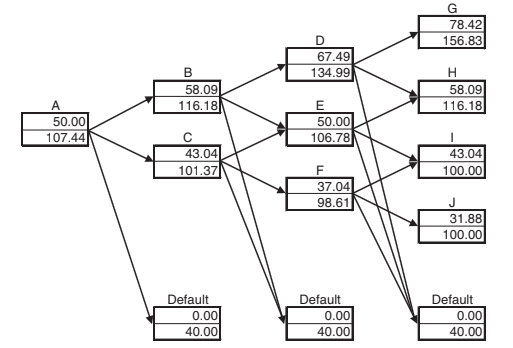

In [ ]:
# Los valores de los parametros en el ejemplo son:
S0 = 50.0
T = 0.75
sigma = 0.30
r = 0.05
q = 0.0
lmbda = 0.01
N = 3
n = 2.0
Z = 100.0
M1 = 113.0
V_recovery = 40.0

# Calculamos el valor
bond_value = convertible_bond_binomial_default(S0, T, sigma, r, q, lmbda, N, n, Z, M1, V_recovery)

print(f"Valor del Bono Convertible (con N={N} pasos): {bond_value:.2f}")

Valor del Bono Convertible (con N=3 pasos): 107.44


### Modelo continuo

In [ ]:
def crank_nicolson_simple_K_M(
        S_min, S_max, t_0, t_f, m, n,
        Z, r, sigma, ratio_conversion,
        dividend_yield=0.0, K=0.0, M=None):
    """
    Crank-Nicolson para bono convertible:
    Tratamos al pago de cupones K como fuente constante, y a los divindendos como un "pago continuo".
    Se podria estructurar como eventos discretos, pero asi parece mas natural.
    El "call price" es constante.

    """

    #Nodos para S y t.
    dS = (S_max - S_min) / m
    dt = (t_f - t_0) / n
    S = np.linspace(S_min, S_max, m+1)
    t = np.linspace(t_0, t_f, n+1)
    print(S[25])

    #En la matriz U, las filas son los precios del activo y las columnas el tiempo
    U = np.zeros((m+1, n+1))

    #Condicion en el vencimiento
    U[:, -1] = np.maximum(ratio_conversion * S, Z)

    #Armamos las matrices A y B (en Crank-Nicolson se usan tal que BU^k+1 = AU^k + F, en este caso es hacia atras en el tiempo)
    A = np.zeros((m-1, m-1))
    B = np.zeros((m-1, m-1))

    for j in range(m-1):
        i = j + 1
        Si = max(S[i], 1e-12)
        a = 0.5 * sigma**2 * Si**2 / dS**2
        b = 0.5 * (r - dividend_yield) * Si / dS

        A[j, j] = 1.0 + 0.5 * dt * (2.0*a + r)
        B[j, j] = 1.0 - 0.5 * dt * (2.0*a + r)

        if j > 0:
            A[j, j-1] = -0.5 * dt * (a - b)
            B[j, j-1] =  0.5 * dt * (a - b)
        if j < m-2:
            A[j, j+1] = -0.5 * dt * (a + b)
            B[j, j+1] =  0.5 * dt * (a + b)

    #Calculamos hacia atras
    for k in range(n-1, -1, -1):
        U_interior_kp1 = U[1:-1, k+1].copy()
        b_vec = B @ U_interior_kp1

        #Fronteras en tiempos k y k+1
        left_kp1 = Z * np.exp(-r * (t_f - t[k+1]))
        left_k   = Z * np.exp(-r * (t_f - t[k]))
        right_kp1 = ratio_conversion * S_max
        right_k   = ratio_conversion * S_max

        #contribuciones de frontera
        i_left = 1
        Si = max(S[i_left], 1e-12)
        aL = 0.5 * sigma**2 * Si**2 / dS**2
        bL = 0.5 * (r - dividend_yield) * Si / dS
        alpha_B_left = 0.5 * dt * (aL - bL)
        alpha_A_left = -0.5 * dt * (aL - bL)
        b_vec[0] += alpha_B_left * left_kp1 + alpha_A_left * left_k


        i_right = m-1
        Si = max(S[i_right], 1e-12)
        aR = 0.5 * sigma**2 * Si**2 / dS**2
        bR = 0.5 * (r - dividend_yield) * Si / dS
        gamma_B_right = 0.5 * dt * (aR + bR)
        gamma_A_right = -0.5 * dt * (aR + bR)
        b_vec[-1] += gamma_B_right * right_kp1 + gamma_A_right * right_k

        #incorporar K constante (trapezoidal CN): dt/2 * (K_{k+1} + K_k) = dt * K (since K es constante)
        b_vec += dt * K * np.ones_like(b_vec)

        #resolver Ax = b
        U_interior_new = np.linalg.solve(A, b_vec)

        #restricciones: primero conversión (piso)
        conver_vals = ratio_conversion * S[1:-1]
        U_interior_new = np.maximum(U_interior_new, conver_vals)

        #call feature:
        if M is not None:
            forced = np.maximum(M, conver_vals)
            U_interior_new = np.minimum(U_interior_new, forced)


        U[1:-1, k] = U_interior_new
        U[0, k] = left_k
        U[-1, k] = right_k

    return U, S, t

Extras

In [ ]:

def comparacion_simple(S0):

    #Precio binomial
    precio_binomial_t0 = convertible_bond_binomial_default(
        S0=S0, T=0.75, sigma=0.3, r=0.05, q=0, lmbda=0.0,
        N=100, n=2, Z=100, M1=113, V_recovery=40)

    #Continuo
    U_edp, S_edp, t_edp = crank_nicolson_simple_K_M(
    S_min=0, S_max=200, t_0=0, t_f=0.75, m=100, n=100,
    Z=100, r=0.05, sigma=0.3, ratio_conversion=2.0, dividend_yield=0, K=0, M=113)


    f = interpolate.interp1d(S_edp, U_edp[:, 0], bounds_error=False, fill_value="extrapolate")
    price_edp = f(S0)

    print("COMPARACIÓN SIMPLE")
    print(f"Precio inicial de la acción: {S0}")
    print(f"Modelo Binomial: {precio_binomial_t0:.2f}")
    print(f"Modelo EDP: {price_edp:.2f}")
    print(f"Diferencia: {abs(price_edp - precio_binomial_t0):.2f}")
    print(f"Diferencia relativa: {abs(price_edp - precio_binomial_t0)/precio_binomial_t0*100:.2f}%")

    #Grafico V(S,0) para el continuo

    plt.figure(figsize=(10, 6))
    plt.plot(S_edp, U_edp[:, 0], 'b-', linewidth=3, label='Valor del bono (t=0)')
    plt.plot(S_edp, 2.0 * S_edp, 'r--', linewidth=2.5, label='Valor de conversión') #n_acciones * S_edp
    plt.axhline(y=100, color='g', linestyle=':', linewidth=2, label='Valor nominal') #Z=100
    plt.margins(0)
    plt.xlabel('Precio del Activo (S)', fontsize=12)
    plt.ylabel('Valor del Bono (V)', fontsize=12)
    #plt.title('Bono convertible para t=0')
    plt.legend(frameon=False, fontsize=15)
    plt.tight_layout()
    plt.show()

def frontera(U, S, n, smooth_win=0):
    T = U.shape[1]
    S_f = np.full(T, np.nan)
    conversion = n * S
    for k in range(T):
        i = np.where(U[:,k] <= conversion)[0]
        if i.size > 0:
            S_f[k] = S[i[0]]
    if smooth_win and smooth_win > 1:         #Suavizado, si no se grafica escalonado
        w = np.ones(smooth_win) / smooth_win
        S_f = np.convolve(S_f, w, mode='same')
    return S_f

50.0
COMPARACIÓN SIMPLE
Precio inicial de la acción: 50
Modelo Binomial: 106.56
Modelo EDP: 106.76
Diferencia: 0.19
Diferencia relativa: 0.18%


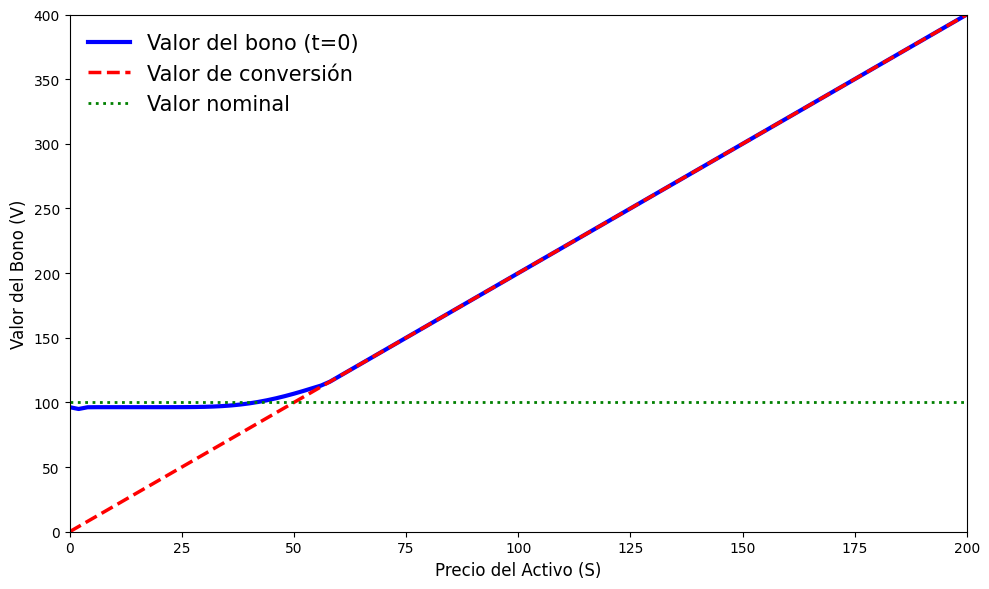

50.0
50.0
50.0


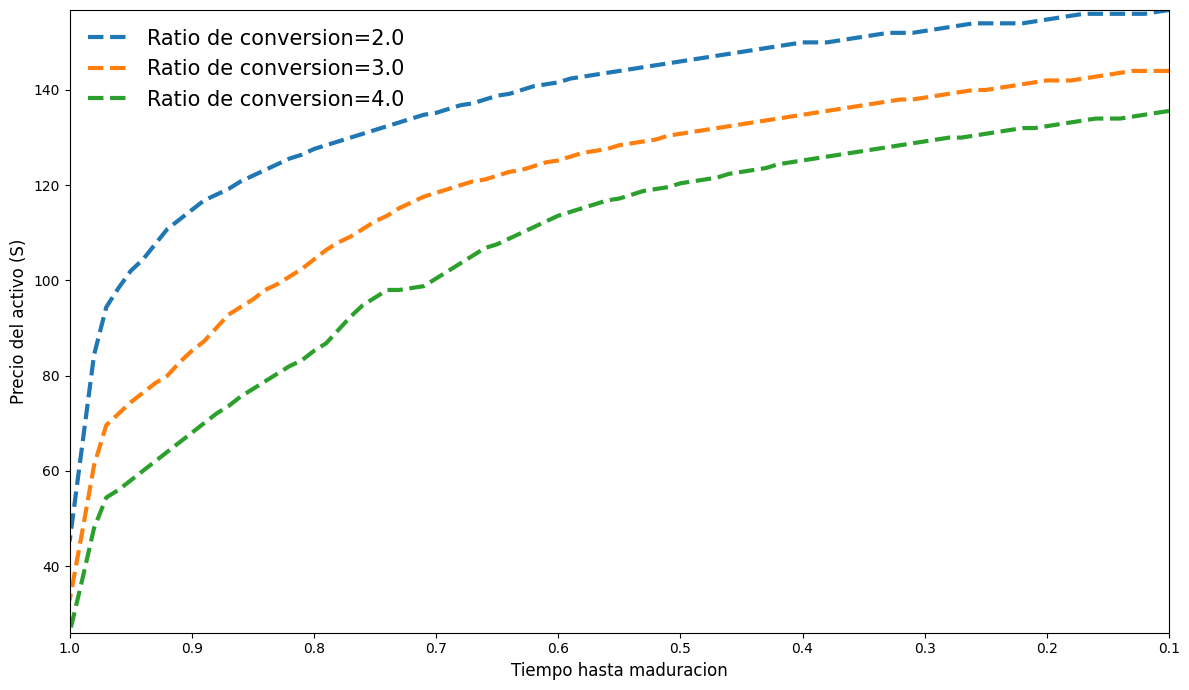

In [ ]:
comparacion_simple(50) #es el ejemplo del libro de Hull.

ns = [2.0, 3.0, 4.0]
plt.figure(figsize=(12,7))
for n in ns:

    U, S, t_nodos = crank_nicolson_simple_K_M(
    S_min=0, S_max=200, t_0=0, t_f=1.0, m=100, n=100,
    Z=100, r=0.05, sigma=0.3, ratio_conversion=n, dividend_yield=0.0, K=0, M=None)

    S_fr = frontera(U, S, n, 5)
    plt.plot(t_nodos[10:], S_fr[10:], '--', linewidth=3, label=f'Ratio de conversion={n}')
plt.margins(0)
plt.gca().invert_xaxis()
plt.xlabel('Tiempo hasta maduracion', fontsize=12)
plt.ylabel('Precio del activo (S)', fontsize=12)
plt.legend(frameon=False, fontsize=15)
plt.grid(False)
plt.tight_layout()
plt.show()